# Compute in Space (Sec 5.9)

Optimize the spatial allocation of on-board compute (heat dissipation)
to avoid a debris collision using thermal radiation pressure.

# Inverse GPU CAM


In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from pathlib import Path

import base
import designer
import raytracing
import physics
import thermal_simulation
import nn
import utils
from utils import load_trajectory

jax.config.update('jax_enable_x64', True)

OBJECT_NAME = 'cuboid_6faces/cuboid_6faces'
SC_MASS_KG = 500.0
EMISSIVITY = 0.9
SRP_WEIGHT_DIR = Path(base.drive_path + 'nn_weights/cuboid_6faces/cuboid_6faces_face_albedo_sweep')
SRP_ALBEDO = 1.0
HEAT_W = 80000.0
BOX_TEMP_C = 100.0
BOX_TEMP_K = BOX_TEMP_C + 273.15
RADIATING_SIDES = 3

/Users/charlesc/anaconda3/envs/photonsxforce/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Box sizing and area scaling
Compute the box size for 80 kW at 100°C with 3 radiating sides using mesh face areas, then scale SRP and thermal forces accordingly.


In [2]:
required_radiating_area = HEAT_W / (EMISSIVITY * physics.STEFAN_BOLTZMANN * BOX_TEMP_K ** 4)
required_face_area = required_radiating_area / RADIATING_SIDES
equiv_face_edge_m = np.sqrt(required_face_area)

mesh = raytracing.load_mesh(base.get_mesh_name(OBJECT_NAME))
faces_np = np.asarray(mesh.faces)
verts_np = np.asarray(mesh.vertices)
tri = verts_np[faces_np[:, :3].astype(int)]
base_total_area = 0.5 * np.linalg.norm(np.cross(tri[:, 1] - tri[:, 0], tri[:, 2] - tri[:, 0]), axis=1).sum()

group_indices = designer._load_group_indices(OBJECT_NAME)
emitter_names = list(group_indices.keys())
face_areas = []
for name in emitter_names:
    mask = faces_np[:, 4] == group_indices[name]
    tri_g = verts_np[faces_np[mask, :3].astype(int)]
    area_g = 0.5 * np.linalg.norm(np.cross(tri_g[:, 1] - tri_g[:, 0], tri_g[:, 2] - tri_g[:, 0]), axis=1).sum()
    face_areas.append(area_g)
face_areas = np.asarray(face_areas)

face_normals = []
for name in emitter_names:
    mask = faces_np[:, 4] == group_indices[name]
    tri_g = verts_np[faces_np[mask, :3].astype(int)]
    normals = np.cross(tri_g[:, 1] - tri_g[:, 0], tri_g[:, 2] - tri_g[:, 0])
    n_sum = normals.sum(axis=0)
    n_unit = n_sum / np.linalg.norm(n_sum)
    face_normals.append(n_unit)
face_normals = np.asarray(face_normals)

remaining = list(range(len(emitter_names)))
face_pairs = []
while remaining:
    i = remaining[0]
    dots = face_normals[i] @ face_normals[remaining[1:]].T
    j_idx = int(np.argmin(dots)) + 1
    j = remaining[j_idx]
    face_pairs.append((i, j))
    remaining.pop(j_idx)
    remaining.pop(0)

pair_indices = np.asarray(face_pairs, dtype=int)
pair_left = jnp.asarray(pair_indices[:, 0])
pair_right = jnp.asarray(pair_indices[:, 1])
FACE_COUNT = face_areas.shape[0]
PAIR_COUNT = pair_indices.shape[0]

pair_areas = []
for i, j in face_pairs:
    pair_areas.append(0.5 * (face_areas[i] + face_areas[j]))
pair_areas = np.asarray(pair_areas)
base_active_area = pair_areas.sum()

length_scale = np.sqrt(required_radiating_area / base_active_area)
AREA_SCALE = float(length_scale ** 2)
base_dims = verts_np.max(axis=0) - verts_np.min(axis=0)
BOX_DIMS_M = base_dims * length_scale
RADIATOR_TEMP_K = BOX_TEMP_K

print(f"Required radiating area (m^2): {required_radiating_area:.2f}")
print(f"Equivalent face edge (m): {equiv_face_edge_m:.2f}")
print(f"Scaled box dims (m): {BOX_DIMS_M}")


Required radiating area (m^2): 80.85
Equivalent face edge (m): 5.19
Scaled box dims (m): [4.02129539 4.02129539 8.04259079]


In [3]:
def realize_face_passthrough(vertices, face, parameters):
    return vertices

def realize_material_passthrough(material, parameters, object_indices=None):
    return material

thermal_design = designer.Design(realize_face_passthrough, realize_material_passthrough, 0)
designer.my_design = thermal_design


RAY_SHAPE = (256, 256)
MC_SAMPLES = 100
random_key = jax.random.PRNGKey(42)

forces, _ = thermal_simulation.evaluate_mesh_sources(
    emitter_names=emitter_names,
    object_name=OBJECT_NAME,
    temperature=RADIATOR_TEMP_K,
    sample_shape=RAY_SHAPE,
    key=random_key,
    mesh=mesh,
    design=thermal_design,
    mc_samples=MC_SAMPLES,
    center_of_mass=jnp.array([0.0, 0.0, 0.0]),
    emissivity=EMISSIVITY,
    max_bounces=1,
    reflectivity=0.0,
)

accels_per_face = jnp.asarray(forces / SC_MASS_KG) * AREA_SCALE


In [4]:
trajectory = load_trajectory(base.drive_path + 'trajectories/gps08.csv', limit=None)
state0_position = jnp.asarray(trajectory.position[0], dtype=jnp.float64)
state0_velocity = jnp.asarray(trajectory.velocity[0], dtype=jnp.float64)
t0 = float(trajectory.time[0])

srp_params = nn.load_nn_parameters(str(SRP_WEIGHT_DIR / 'force_parameters.bin'))
srp_ray_stats = nn.load_nn_parameters(str(SRP_WEIGHT_DIR / 'force_ray_stats.bin'))
srp_force_stats = nn.load_nn_parameters(str(SRP_WEIGHT_DIR / 'force_target_stats.bin'))
srp_ray_stats = (jnp.asarray(srp_ray_stats[0], dtype=jnp.float64), jnp.asarray(srp_ray_stats[1], dtype=jnp.float64))
srp_force_stats = (jnp.asarray(srp_force_stats[0], dtype=jnp.float64), jnp.asarray(srp_force_stats[1], dtype=jnp.float64))

def make_srp_provider(albedo):
    x_min, x_max = srp_ray_stats
    y_min, y_max = srp_force_stats
    face_count = int(srp_ray_stats[0].shape[0] - 3)
    albedo_vec = jnp.ones((face_count,), dtype=jnp.float64) * jnp.asarray(albedo, dtype=jnp.float64)
    sun_positions = trajectory.sun
    sun_times = trajectory.time
    @jax.jit
    def provider(position, time):
        sun_pos = utils.sample_moonsun_cubic(time, sun_positions, sun_times)
        lat, lon = physics.sun_direction_in_sc_frame(position, sun_pos)
        sun_dir = utils.lat_lon_to_cart(lat, lon)
        nn_input = jnp.concatenate((sun_dir, albedo_vec))
        whitened = nn.whiten_with_stats(nn_input, (x_min, x_max)).astype(jnp.float32)
        pred_pm1 = nn.mlp(whitened, srp_params)
        pred01 = 0.5 * (pred_pm1 + 1.0)
        force_sc = nn.unwhiten(pred01, (y_min, y_max))
        force_sc = jnp.asarray(force_sc, dtype=jnp.float64)
        x_sc, y_sc, z_sc = physics.sc_attitude(position, sun_pos)
        rotation_matrix = jnp.stack([x_sc, y_sc, z_sc], axis=1)
        force_eci = rotation_matrix @ force_sc
        shadow = physics.eclipse_model(position, sun_pos)
        force_eci = jnp.where(shadow == 0, jnp.zeros(3, dtype=jnp.float64), force_eci * shadow)
        return (force_eci * AREA_SCALE) / SC_MASS_KG
    return provider

srp_provider = make_srp_provider(SRP_ALBEDO)

def semi_major_axis(positions, velocities):
    r = jnp.linalg.norm(positions, axis=-1)
    v2 = jnp.sum(velocities * velocities, axis=-1)
    return 1.0 / (2.0 / jnp.maximum(r, 1e-6) - v2 / physics.MU)

SIM_DURATION_S = 72 * 3600.0
STEP_SIZE_S = 120.0
STEP_COUNT = int(SIM_DURATION_S / STEP_SIZE_S)
NUM_SEGMENTS = 210
STEPS_PER_SEGMENT = STEP_COUNT // NUM_SEGMENTS

times = t0 + (jnp.arange(STEP_COUNT) + 1) * STEP_SIZE_S
COLLIDE_TIME_S = 36 * 3600.0

r0 = jnp.linalg.norm(state0_position)
v0_sq = jnp.sum(state0_velocity ** 2)
sma0 = 1.0 / (2.0 / r0 - v0_sq / physics.MU)

def logits_to_activations(logits):
    pair_weights = jax.nn.softmax(logits, axis=-1)
    activations = jnp.zeros((pair_weights.shape[0], FACE_COUNT), dtype=jnp.float64)
    activations = activations.at[:, pair_left].set(pair_weights[..., 0])
    activations = activations.at[:, pair_right].set(pair_weights[..., 1])
    return activations

def propagate_with_schedule(logits):
    activations = logits_to_activations(logits)
    def step_fn(carry, step_idx):
        pos, vel = carry
        segment_idx = step_idx // STEPS_PER_SEGMENT
        segment_idx = jnp.minimum(segment_idx, NUM_SEGMENTS - 1)
        accel = jnp.sum(activations[segment_idx][:, None] * accels_per_face, axis=0)
        time = t0 + step_idx * STEP_SIZE_S
        srp_accel = srp_provider(pos, time)
        r = jnp.linalg.norm(pos)
        grav_accel = -physics.MU * pos / (r ** 3)
        total_accel = grav_accel + accel + srp_accel
        new_vel = vel + total_accel * STEP_SIZE_S
        new_pos = pos + new_vel * STEP_SIZE_S
        return (new_pos, new_vel), (new_pos, new_vel)
    init_state = (state0_position, state0_velocity)
    _, history = jax.lax.scan(step_fn, init_state, jnp.arange(STEP_COUNT))
    return history

def propagate_gravity_only():
    def step_fn(carry, _):
        pos, vel = carry
        r = jnp.linalg.norm(pos)
        grav_accel = -physics.MU * pos / (r ** 3)
        new_vel = vel + grav_accel * STEP_SIZE_S
        new_pos = pos + new_vel * STEP_SIZE_S
        return (new_pos, new_vel), (new_pos, new_vel)
    init_state = (state0_position, state0_velocity)
    _, history = jax.lax.scan(step_fn, init_state, jnp.arange(STEP_COUNT))
    return history


baseline_orbit_positions, baseline_orbit_velocities = propagate_gravity_only()
collide_idx = int(COLLIDE_TIME_S / STEP_SIZE_S) - 1
collider_positions = baseline_orbit_positions[::-1]
shift = collide_idx - (collider_positions.shape[0] - 1 - collide_idx)
collider_positions = jnp.roll(collider_positions, shift, axis=0)

COLLIDE_WINDOW_S = 1.0 * 3600.0
RECOVER_START_S = COLLIDE_TIME_S + 3 * 3600.0
ORBIT_WEIGHT = 0.3
RECOVER_WEIGHT = 3.0
TERMINAL_WEIGHT = 5.0
COLLISION_WEIGHT = 1000.0
COLLISION_POINT_WEIGHT = 5.0
BINARY_WEIGHT = 1.0
def loss_fn(logits):
    positions, velocities = propagate_with_schedule(logits)
    track_dist = jnp.linalg.norm(positions - baseline_orbit_positions, axis=1)
    collide_dist = jnp.linalg.norm(positions - collider_positions, axis=1)
    collision_weight = jnp.exp(-0.5 * ((times - (t0 + COLLIDE_TIME_S)) / COLLIDE_WINDOW_S) ** 2)
    orbit_weight = 1.0 - 0.9 * collision_weight
    recover_mask = (times >= (t0 + RECOVER_START_S)).astype(jnp.float64)
    orbit_error = jnp.mean(track_dist * orbit_weight)
    recover_error = jnp.sum(track_dist * recover_mask) / jnp.sum(recover_mask)
    collision_reward = jnp.sum(collide_dist * collision_weight) / jnp.sum(collision_weight)
    collision_point = collide_dist[collide_idx]
    terminal_error = jnp.linalg.norm(positions[-1] - baseline_orbit_positions[-1])
    activations = logits_to_activations(logits)
    binary_penalty = jnp.mean(activations * (1.0 - activations))
    return (
        ORBIT_WEIGHT * orbit_error
        + RECOVER_WEIGHT * recover_error
        + TERMINAL_WEIGHT * terminal_error
        - COLLISION_WEIGHT * collision_reward
        - COLLISION_POINT_WEIGHT * collision_point
        + BINARY_WEIGHT * binary_penalty
    )

loss_and_grad = jax.jit(jax.value_and_grad(loss_fn))


In [5]:
import optax

face_count = accels_per_face.shape[0]
baseline_logits = jnp.zeros((NUM_SEGMENTS, PAIR_COUNT, 2))

random_seeds = [0, 1, 2]
random_logits_list = []
logit_high = 6.0
for seed in random_seeds:
    rng = np.random.default_rng(seed)
    choices = rng.integers(0, 2, size=(NUM_SEGMENTS, PAIR_COUNT))
    pair_logits = np.zeros((NUM_SEGMENTS, PAIR_COUNT, 2), dtype=np.float64)
    pair_logits[..., 0] = np.where(choices == 0, logit_high, -logit_high)
    pair_logits[..., 1] = np.where(choices == 0, -logit_high, logit_high)
    random_logits_list.append(jnp.asarray(pair_logits, dtype=jnp.float64))

logits = baseline_logits

optimizer = optax.adam(0.05)
opt_state = optimizer.init(logits)

NUM_STEPS = 200
loss_history = []
for step in range(NUM_STEPS):
    loss_val, grads = loss_and_grad(logits)
    updates, opt_state = optimizer.update(grads, opt_state, logits)
    logits = optax.apply_updates(logits, updates)
    loss_history.append(float(loss_val))


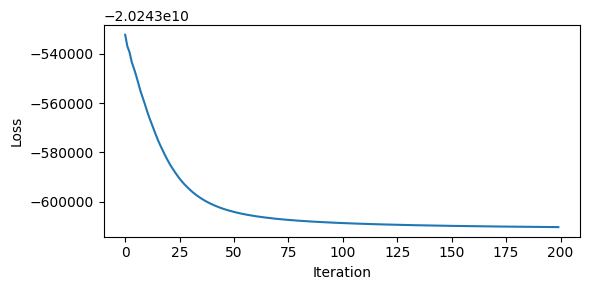

In [6]:
plt.figure(figsize=(6, 3))
plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()


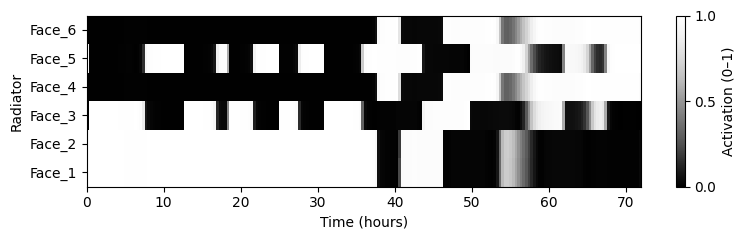

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

final_activations = np.asarray(logits_to_activations(logits))
segment_times_hours = np.arange(NUM_SEGMENTS + 1) * (SIM_DURATION_S / NUM_SEGMENTS / 3600.0)
radiator_edges = np.arange(len(emitter_names) + 1)

fig, ax = plt.subplots(figsize=(8, 2.5))

norm = Normalize(vmin=0.0, vmax=1.0, clip=True)

mesh = ax.pcolormesh(
    segment_times_hours,     # edges (N+1)
    radiator_edges,          # edges (M+1)
    final_activations.T,     # C shape must be (M, N)
    shading="flat",
    cmap="Greys_r",          # 0=black, 1=white (reversed Greys)
    norm=norm,
    edgecolors="none",
    antialiased=False,
)

ax.set_yticks(np.arange(len(emitter_names)) + 0.5)
ax.set_yticklabels(emitter_names)
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Radiator")

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_ticks([0, 0.5, 1])
cbar.set_label("Activation (0–1)")

plt.tight_layout()

os.makedirs(str(base.PROJECT_ROOT / "plots" / "gpu_experiments"), exist_ok=True)
plt.savefig(
    str(base.PROJECT_ROOT / "plots" / "gpu_experiments" / "inverse_gpu_cam_radiator_schedule.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

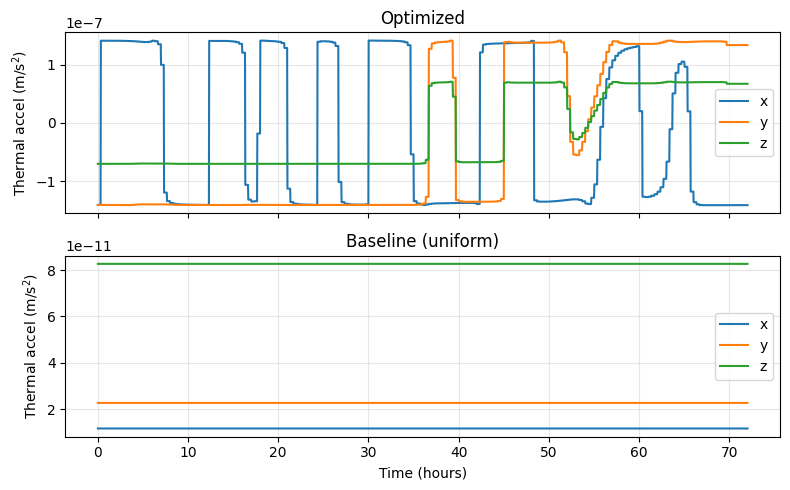

In [8]:
# Thermal acceleration: optimized vs baseline (zero logits)
time_hours = (np.arange(STEP_COUNT) + 1) * STEP_SIZE_S / 3600.0

def schedule_accels(logits):
    activations = logits_to_activations(logits)
    step_idx = jnp.arange(STEP_COUNT)
    seg_idx = jnp.minimum(step_idx // STEPS_PER_SEGMENT, NUM_SEGMENTS - 1)
    accel_per_seg = jax.vmap(lambda i: jnp.sum(activations[i][:, None] * accels_per_face, axis=0))(jnp.arange(NUM_SEGMENTS))
    return accel_per_seg[seg_idx]

thermal_opt = np.asarray(schedule_accels(logits))
thermal_baseline = np.asarray(schedule_accels(baseline_logits))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
for j, axis in enumerate(['x', 'y', 'z']):
    ax1.plot(time_hours, thermal_opt[:, j], label=axis)
ax1.set_ylabel('Thermal accel (m/s$^2$)')
ax1.set_title('Optimized')
ax1.legend()
ax1.grid(alpha=0.3)

for j, axis in enumerate(['x', 'y', 'z']):
    ax2.plot(time_hours, thermal_baseline[:, j], label=axis)
ax2.set_ylabel('Thermal accel (m/s$^2$)')
ax2.set_xlabel('Time (hours)')
ax2.set_title('Baseline (uniform)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

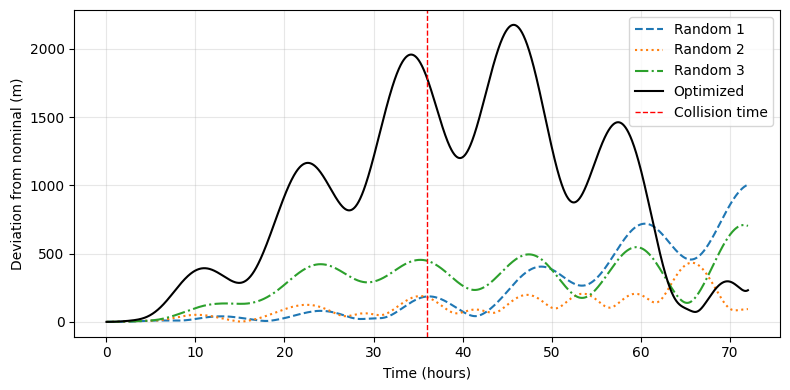

In [9]:
# Deviation from nominal orbit
time_hours = (np.arange(STEP_COUNT) + 1) * STEP_SIZE_S / 3600.0

case_logits = {f"Random {i+1}": random_logits_list[i] for i in range(len(random_logits_list))}
case_logits["Optimized"] = logits

styles = {"Random 1": "--", "Random 2": ":", "Random 3": "-.", "Optimized": "-"}

fig, ax = plt.subplots(figsize=(8, 4))
for name, logit_set in case_logits.items():
    pos, vel = propagate_with_schedule(logit_set)
    dev = np.asarray(jnp.linalg.norm(pos - baseline_orbit_positions, axis=1))
    ax.plot(time_hours, dev, styles[name], label=name, color='k' if name == 'Optimized' else None)

ax.axvline(COLLIDE_TIME_S / 3600, color='r', ls='--', lw=1, label='Collision time')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Deviation from nominal (m)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(base.PROJECT_ROOT / 'plots/gpu_experiments/inverse_gpu_cam_distance.svg'))
plt.show()